Lex Albrandt  
CS 445
HW 3  
  
# Question 1  
  
## 1a)  
  

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

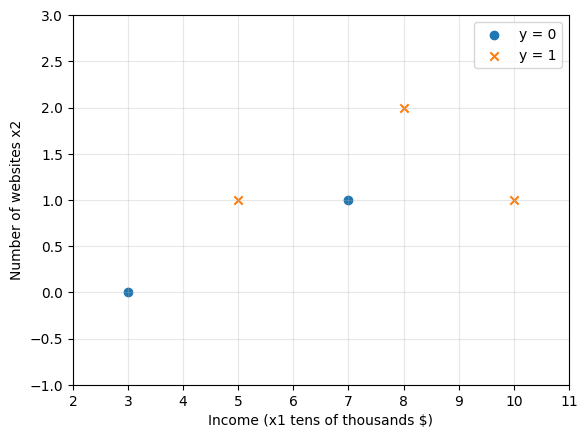

In [2]:
x1 = np.array([3, 5, 7, 8, 10])
x2 = np.array([0, 1, 1, 2, 1])
y = np.array([0, 1, 0, 1, 1])

mask0 = (y == 0)
mask1 = (y == 1)



plt.figure()
plt.scatter(x1[mask0], x2[mask0], marker = 'o', label = 'y = 0')
plt.scatter(x1[mask1], x2[mask1], marker = 'x', label = 'y = 1')

# set limits
plt.xlim(2, 11)
plt.ylim(-1, 3) 
plt.xlabel('Income (x1 tens of thousands $)')
plt.ylabel('Number of websites x2')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

## 1b)  
  

In [3]:
# Create feature matrix
X = np.column_stack((x1, x2))
print(X)

[[ 3  0]
 [ 5  1]
 [ 7  1]
 [ 8  2]
 [10  1]]


Weight vector w: [0.38962663 0.40322108]
Biase b: -2.487444443412304


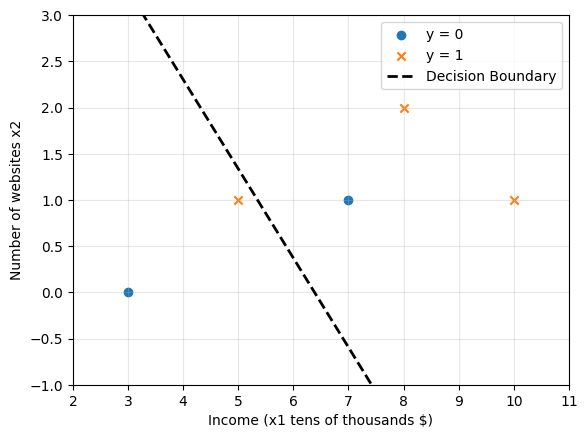

In [4]:
# Identify a linear fit with Logistic Regression
clf = LogisticRegression()

# Decision boundary line
# z = w1x1 + w2x2 + b
clf.fit(X, y)

# weight vector and bias
w = clf.coef_[0]
b = clf.intercept_[0]

print(f"Weight vector w: {w}")
print(f"Biase b: {b}")

# Values for boundary line
x_vals = np.linspace(2, 11, 100)
y_vals = -(w[0] * x_vals + b)/w[1]

mask0 = (y == 0)
mask1 = (y == 1)

plt.figure()
plt.scatter(x1[mask0], x2[mask0], marker = 'o', label = 'y = 0')
plt.scatter(x1[mask1], x2[mask1], marker = 'x', label = 'y = 1')
plt.plot(x_vals, y_vals, 'k--', label = "Decision Boundary", linewidth = 2)
plt.xlim(2, 11)
plt.ylim(-1, 3)
plt.xlabel('Income (x1 tens of thousands $)')
plt.ylabel('Number of websites x2')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

## 1c)
  

In [5]:
# Find z-values based on regression model from 1b
# gives linear score for each point
z = X @ w + b
print(f"z-values: {z}")

# Convert z-values with sigmoid
p = 1 / (1 + np.exp(-z))
print(f"P(y=1 | x): {p}")

# Find least likely sample
least_likely = np.argmin((p))
print(f"Least likely sample: {least_likely + 1}")

z-values: [-1.31856455 -0.13609021  0.64316305  1.43601076  1.81204294]
P(y=1 | x): [0.21105721 0.46602986 0.65546812 0.80783613 0.8596086 ]
Least likely sample: 1


The above calculations show that the first sample (at index 0 with income of $3000) is  
least likely to donate.  
  
# Question 2  
  
## 2a)  
  
To compute $\frac{\partial f}{\partial x}$ for the function $f(x) = x_1 + {x_2}{x_3} + x_1^3$ we must consider each partial  
derivative for $x_1$, $x_2$, and $x_3$.
$$\frac{\partial f}{\partial {x_1}} = \frac{\partial f}{\partial x_1}(x_1 + {x_2}{x_3} + x_1^3) = 1 + 6x_1^2$$
$$\frac{\partial f}{\partial {x_2}} = \frac{\partial f}{\partial x_1}(x_1 + {x_2}{x_3} + x_1^3) = x_3$$
$$\frac{\partial f}{\partial {x_3}} = \frac{\partial f}{\partial x_1}(x_1 + {x_2}{x_3} + x_1^3) = x_2$$  
  
We then combine the above results into a gradient vector $\nabla_x f$ as follows:  
$$
\nabla_{\mathbf{x}} f=
\begin{pmatrix}
\frac{\partial f}{\partial x_1} \\
\frac{\partial f}{\partial x_2} \\
\frac{\partial f}{\partial x_3}
\end{pmatrix} =
\begin{pmatrix}
1 + 6x_1^2 \\
x_3 \\
x_2
\end{pmatrix}
$$  
  
## 2b)  
  
In order to compute $\frac{\partial L}{\partial x}$ we must first compute the partial derivatives of each of the componenet  
pieces as follows:  
$$\frac{\partial L}{\partial \hat{y}} = \frac{1}{2}(\hat{y}-y)^{2} = \hat{y}-y$$
$$\frac{\partial \hat{y}}{\partial z} = \hat{y}(1 - \hat{y})$$
$$\frac{\partial z}{\partial x} = w$$
We must then apply the chain rule:  
$$\frac{\partial L}{\partial x} = (\hat{y}-y) \cdot \hat{y}(1-\hat{y}) \cdot w$$  
  
# Question 3  
  
## 3a)   
  
For the given equation $f(w) = aw^2 + bw + c$, the gradient descent converges to a global minima if $a > 0$ and the learning rate is  
sufficiently small with regards to $a$
  
## 3b)  
  
The global minimum occurs when:  
$$f'(w)=0$$  
Compute the derivative:  
$$f'(w) = 2aw + b$$  
Set equal to zero:  
$$2aw + b = 0$$  
Solve:  
$$w^* = -\frac{b}{2a}$$

# Question 4  
  

In [6]:
df = pd.read_csv('./banana_quality.csv')
# Map good to 1 and bad to 0
df["Quality"] = df['Quality'].map({"Good": 1, "Bad": 0})

# Get feature matrix and target vector
X = df.drop(columns = ["Quality"]).values
y = df["Quality"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Define function for loss and gradient for given vector
def feval(w, X, y):
    
    # construct transform matrix
    n_samples = X.shape[0]
    A = np.column_stack((np.ones(n_samples, ), X))

    # Loss is BCE
    z = A.dot(w)
    y_hat = sigmoid(z)
    f = -np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

    # gradient
    df_dz = y_hat - y
    fgrad = A.T.dot(df_dz) / n_samples

    return f, fgrad

# Define Gradient Descent function
def gradient_descent(X, y, num_iterations, learning_rate):

    # n_samples is not used, but is required for return from X.shape
    n_samples, n_features = X.shape

    w = np.zeros(n_features + 1)
    
    for it in range(num_iterations):

        # Compute loss and gradient
        loss, grad = feval(w, X, y)

        # update weights
        w = w - learning_rate * grad

        # print loss
        if it % 100 == 0:
            print(f"Iterations {it}, Loss = {loss:.4f}")
    
    return w

# Hyperparameters
num_iterations = 2000
learning_rate = 1e-2

# Train model
weights = gradient_descent(X_train, y_train, num_iterations, learning_rate)

# Make predictions
def predict(X, w):
    n_samples = X.shape[0]
    A = np.column_stack((np.ones(n_samples), X))
    z = A.dot(w)
    y_hat = sigmoid(z)

    # thresholds @ 0.5
    return (y_hat >= 0.5).astype(int)

# Test accuracy
y_pred = predict(X_test, weights)
accuracy = np.mean(y_pred == y_test)
print(f"Test accuracy: {accuracy}")

Iterations 0, Loss = 4436.1420
Iterations 100, Loss = 3619.9801
Iterations 200, Loss = 3152.9211
Iterations 300, Loss = 2861.7734
Iterations 400, Loss = 2665.9561
Iterations 500, Loss = 2526.2912
Iterations 600, Loss = 2422.1276
Iterations 700, Loss = 2341.7206
Iterations 800, Loss = 2277.9488
Iterations 900, Loss = 2226.2597
Iterations 1000, Loss = 2183.6136
Iterations 1100, Loss = 2147.9058
Iterations 1200, Loss = 2117.6339
Iterations 1300, Loss = 2091.6973
Iterations 1400, Loss = 2069.2713
Iterations 1500, Loss = 2049.7262
Iterations 1600, Loss = 2032.5728
Iterations 1700, Loss = 2017.4254
Iterations 1800, Loss = 2003.9759
Iterations 1900, Loss = 1991.9753
Test accuracy: 0.880625
